# Bigram / Mini Transformer Language Model

Character-level language model trained on Tiny Shakespeare, built from a bigram baseline up to a small Transformer.

## 1. Setup

In [4]:
import math
import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. Config

In [5]:
block_size = 64
n_embd = 128 
n_head = 4
n_layer = 6
dropout = 0.2

batch_size = 32
learning_rate = 3e-4
max_iters = 5000
eval_interval = 500
eval_iters = 100
grad_clip = 1.0

checkpoint_path = "model.pt"

## 3. Load Data

In [6]:
with open("tiny shakespeare.txt", "r") as f:
    text = f.read()

## 4. Build the Character Vocabulary

In [7]:
vocab = sorted(list(set(text)))
vocab_size = len(vocab)

## 5. Encode / Decode

In [8]:
encod = {ch: i for i, ch in enumerate(vocab)}
decod = {i: ch for i, ch in enumerate(vocab)}

encode = lambda s: [encod[i] for i in s]
decode = lambda l: ''.join([decod[i] for i in l])

print(encode("hello world"))
decode(encode("hello world"))

[46, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]


'hello world'

## 6. Train / Test Split

In [9]:
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Data shape: {data.shape}")
if data.ndim > 1:
    data = data.flatten()
    print(f"Flattened data shape: {data.shape}")

n = int(0.9 * len(data))
train_set = data[:n]
test_set = data[n:]

(len(test_set) / (len(train_set) + len(test_set))) * 100

Data shape: torch.Size([1115394])


10.000053792650847

## 7. Batching

Samples a fresh random batch on every call instead of pre-materializing every window in memory.

In [10]:
def get_batch(split):
    source = train_set if split == "train" else test_set
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print(f"xb shape: {xb.shape}")
print(f"yb shape: {yb.shape}")

xb shape: torch.Size([32, 64])
yb shape: torch.Size([32, 64])


## 8. Transformer Building Blocks

In [11]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, dropout):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)

        tril = torch.tril(torch.ones(T, T)).to(x.device)
        wei = wei.masked_fill(tril == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, dropout):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, n_embd, dropout) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size, n_embd, dropout)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## 9. Baseline: Bigram Language Model

In [12]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for i in range(max_new_tokens):
            logits, _ = self(idx)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

bigram_model = BigramLanguageModel(vocab_size)
xb, yb = get_batch("train")
logits, loss = bigram_model(xb, yb)
print(f"Bigram Logits shape: {logits.shape}")
print(f"Bigram Loss: {loss}")

Bigram Logits shape: torch.Size([2048, 65])
Bigram Loss: 4.65866231918335


## 10. The Full Model — Small Transformer

In [13]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[Block(n_embd, n_head, dropout) for _ in range(n_layer)])

        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb

        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for i in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = LanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout).to(device)
xb, yb = get_batch("train")
logits, loss = model(xb, yb)
print(f"Logits shape: {logits.shape}")
print(f"Loss: {loss}")
print(f"Params: {sum(p.numel() for p in model.parameters()) / 1e3:.1f}K")

Logits shape: torch.Size([32, 64, 65])
Loss: 4.33754825592041
Params: 1212.5K


## 11. Prediction Before Training

In [14]:
start_context = torch.zeros((1, 1), dtype=torch.long, device=device)

print("--- BEFORE TRAINING ---")
untrained_output = model.generate(start_context, max_new_tokens=300)[0].tolist()
print(decode(untrained_output))

--- BEFORE TRAINING ---

jcnQxijI'IM;yxnPkhtJeOlDvlNq&ExvbuRRDu&b-&FaXS&oCP&eOVKJs'eGB& Y bcsFiMJG'Tm Uk$&.UC.'?ql$dTli:Bsw
ohbliBgVhIgizBCp3K
waIHZbmCgNrNtQ.Ydd:bxa:ymo'sz?chu
MT:QJZegZTGmMomyNlc3Cds'j&Eq m$y?fsRAKRDgw.fvtEHcCNIh.y3x$ YHOhDrK,WC;F
P3KV$,mCZIxsKANgGR$RAYJ  :AsMOmQVVsc3cCVqGCIIzCMiAlBxh'j?ssqGzRLC-egVzixImyr


## 12. Training Loop

Loss is averaged over `eval_iters` batches for a stable estimate. Gradient clipping and a cosine learning-rate schedule are applied every step.

In [15]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "test"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters)

train_losses = []
test_losses = []

for i in range(max_iters):
    if i % eval_interval == 0 or i == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        test_losses.append(losses["test"])
        print(f"Iteration {i}: Train Loss {losses['train']:.4f} | Test Loss {losses['test']:.4f}")

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    scheduler.step()

print(f"Final Loss: {loss.item():.4f}")

Iteration 0: Train Loss 4.3434 | Test Loss 4.3440
Iteration 500: Train Loss 2.2720 | Test Loss 2.2889
Iteration 1000: Train Loss 2.0416 | Test Loss 2.0834
Iteration 1500: Train Loss 1.9043 | Test Loss 1.9810
Iteration 2000: Train Loss 1.8113 | Test Loss 1.9263
Iteration 2500: Train Loss 1.7574 | Test Loss 1.8782
Iteration 3000: Train Loss 1.7195 | Test Loss 1.8581
Iteration 3500: Train Loss 1.6924 | Test Loss 1.8420
Iteration 4000: Train Loss 1.6941 | Test Loss 1.8293
Iteration 4500: Train Loss 1.6769 | Test Loss 1.8239
Iteration 4999: Train Loss 1.6786 | Test Loss 1.8280
Final Loss: 1.7826


## 13. Plot Loss Curve

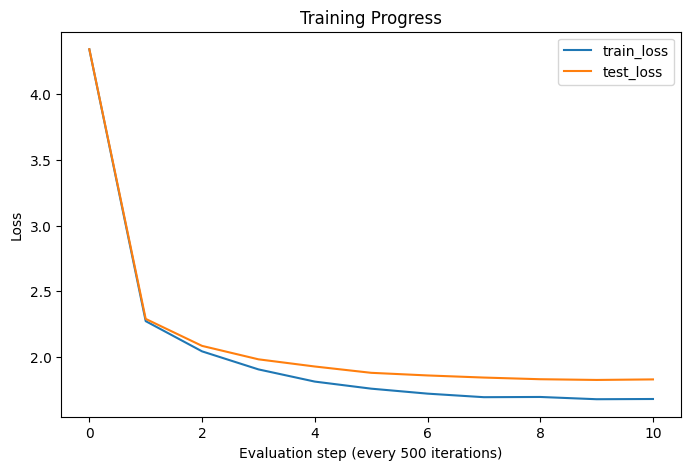

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train_loss")
plt.plot(test_losses, label="test_loss")
plt.xlabel(f"Evaluation step (every {eval_interval} iterations)")
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()
plt.show()

## 14. Save & Reload Checkpoint

In [17]:
torch.save(model.state_dict(), checkpoint_path)
print(f"Saved checkpoint to {checkpoint_path}")

loaded_model = LanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout).to(device)
loaded_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
loaded_model.eval()
print("Checkpoint loaded successfully")

Saved checkpoint to model.pt
Checkpoint loaded successfully


## 15. Prediction After Training

In [18]:
print("--- AFTER TRAINING ---")
trained_output = loaded_model.generate(start_context, max_new_tokens=1000)[0].tolist()
print(decode(trained_output))

--- AFTER TRAINING ---

And my heare this kisnow that he warder viself I
am thou nove beeeming like hath wonch weich woll Ladon To me;
And mors of the ware seet that have have me yie,
May, That I speak take in the hope all give letted
In Canings for he willl thy is tople thou dow a weops.

LORD Shalt my gave ence sputon:
That wet You yould be henry Purritest, I him alains;
Stent percanass; what at d'en this packious,
To the wife me droZer
I'll to say a groode on uparroin, in mast hoch terst.
What give, and chournons, there or corn in me vale,
Of Lordiento it lawer'd that prled be's be.

DUKE UMENCENCETIO:
That for let Bustain heretardiande
Great u there to to that didied would youLther this such at
To graill grace with derrave!
By is, 't live not new are with a they for to which call Rome,
Noo to shorrew to self; why moath truske that ladow;
For contrey yet for op friepoo, here for oftitior
To nebfon. Jursel: hith a most here kibs, this and
Thee whreed an uncess thy becons goods mades 